# Differentiable predictive control (DPC) for PDE Control using TI-DeepONet in Neuromancer

Recreating [DPC](https://www.sciencedirect.com/science/article/pii/S0959152422000981) using TI-DeepONet (Time-integrated Deep Operator Network) Heat equation notebook example in Neruomancer from (https://github.com/Centrum-IntelliPhysics/PDEControl_DPC/tree/main).

Here, we use the trained TI-DON (see example [examples/neural_operators/Part_8_TIDON_HEAT.ipynb](../neural_operators/Part_8_TIDON_HEAT.ipynb)) 

This example presents the a framework to do DPC for PDE control implemented in Neuromancer.

<img src="https://github.com/Centrum-IntelliPhysics/PDEControl_DPC/blob/main/DPC_NO.png?raw=true" width="700">
<!-- <img src="https://arxiv.org/html/2505.17341v2/x2.png?raw=true" width="700"> -->

### References

[1] [Sarkar, D. R., Drgoňa, J., & Goswami, S. (2025). Learning to Control PDEs with Differentiable Predictive Control and Time-Integrated Neural Operators. arXiv preprint arXiv:2511.08992.](https://arxiv.org/abs/2511.08992)


## Problem Setup

### 1. TI-DON Parametrisation
* **State Dynamics ($\mathcal{G}_\theta$):** We train a neural operator $\mathcal{G}_\theta$ to learn the instantaneous time derivative:
    $$
    \mathcal{G}_\theta : (u(t), f(t)) \mapsto \partial_t u
    $$
    This learned operator is integrated using **RK4** (Runge-Kutta 4) for time evolution.
    
* **Control Representation ($f$):** Control inputs are parametrized via **Gaussian basis functions**:
    $$
    f(x, t) = \sum_{i=1}^{n} f_i(t) \cdot \exp \left( - \frac{(x - \mu_i)^2}{2\sigma^2} \right)
    $$
    * **Actuators:** $n=4$ actuators at $\mu_i \in \{0.2, 0.4, 0.6, 0.8\}$ with spread $\sigma = 0.1$.
    * **Amplitudes:** $f_i(t)$ are learned time-varying amplitudes bounded by $|f_i(t)| \le 40$.

### 2. Physical System: Heat Equation
The underlying dynamics follow the Heat Equation with homogeneous Dirichlet boundary conditions:
$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2} + f(x, t), \quad x \in [0, 1], ~ t \in [0, 0.4]
$$
where $\alpha = 0.1$ is the thermal diffusivity.


### Imports

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn


In [2]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random seed
seed = 1234
torch.manual_seed(seed)
# NumPy random seed
np.random.seed(seed)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


# DPC code starts


## Data loading for HEAT equation

* **Method:** Finite Difference Method (FDM) with the unconditionally stable **Crank-Nicolson scheme**.
* **Dataset:** 3000 samples with initial conditions from a Gaussian Random Field (GRF).
* **Resolution:** Spatial $\Delta x = 10^{-2}$, Temporal $\Delta t = 10^{-3}$.

The training and testing datasets for all heat equation PDE systems is available at this [link](https://livejohnshopkins-my.sharepoint.com/:f:/g/personal/droysar1_jh_edu/ElrQ5bd7MKRLv5bfn3_Rg9gBBbJHXQHOztZ37scwJGjbqQ?e=aOTLQC). 

Download `heat_smooth_f_dataset.npz`


In [3]:
data_path = "pathto/datasets/heat_smooth_f_dataset.npz"
data_path = "/home/pk222/projects/PDEControl_DPC/datasets/heat_smooth_f_dataset.npz"

In [4]:
dataset = np.load(data_path)  # total 3000 samples available
num_samples = 100  # samples or number of trajectories to load, original has 500

solutions = torch.from_numpy(
    dataset["solutions"][:num_samples]
)  # shape: (samples, T+1, N)
controls = torch.from_numpy(dataset["controls"][:num_samples])  # shape: (samples, T, 4)
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1)  # shape: (N, 1)
dt = dataset["dt"]  # likely a scalar numpy value


print(f"Loaded {num_samples}/{dataset['solutions'].shape[0]} samples:")
print("solutions:", solutions.shape)  # (samples, T+1, N)
print("controls:", controls.shape)  # (samples, T, 4)
print("x:", x_cord.shape)
print("dt:", dt)


Loaded 100/3000 samples:
solutions: torch.Size([100, 401, 100])
controls: torch.Size([100, 400, 4])
x: torch.Size([100, 1])
dt: 0.001


## Data generation for control policy training

We generate data for the policy learning. Initialisation and finals are created using `generate_grf_pairs`. Controls are initialised using `dataset["controls"][:num_samples]` from the original dataset

In [5]:
import gpytorch

train_frac = 0.8  # also for DPC
# x_cord, same as trunk_grid
length_scale = 0.2
variance = 1.0
num_modes = 64
# seed=config["seed"]
nsteps = 100

In [6]:
def rbf_covariance_gpytorch(x_grid, lengthscale_eff, variance):
    """Compute RBF covariance using GPyTorch on CPU."""
    x = torch.tensor(x_grid, dtype=torch.float64).view(-1, 1)
    rbf_kernel = gpytorch.kernels.RBFKernel(ard_num_dims=1)
    rbf_kernel.lengthscale = torch.tensor(float(lengthscale_eff), dtype=torch.float64)
    scale_kernel = gpytorch.kernels.ScaleKernel(rbf_kernel)
    scale_kernel.outputscale = torch.tensor(float(variance), dtype=torch.float64)
    with torch.no_grad():
        cov = scale_kernel(x).evaluate()
    return cov.cpu().numpy().astype(np.float64)


def create_1d_grf_zero_boundary(x_grid, lengthscale, variance, kernel_type, seed):
    """Generate a single 1D GRF sample with zero boundary conditions using an RBF kernel."""
    _ = kernel_type
    if seed is not None:
        np.random.seed(int(seed))

    x = np.asarray(x_grid, dtype=np.float64).reshape(-1)
    n_points = x.shape[0]
    if n_points < 3:
        raise ValueError("x_grid must have at least 3 points for interior sampling.")

    boundary_indices = [0, n_points - 1]
    interior_indices = list(range(1, n_points - 1))

    lengthscale = float(lengthscale)
    if lengthscale <= 0.0:
        raise ValueError("lengthscale must be positive.")
    span = float(x[-1] - x[0])
    lengthscale_eff = lengthscale * span if span != 0.0 else lengthscale

    cov_full = rbf_covariance_gpytorch(x, lengthscale_eff, variance)
    cov_full = cov_full + 1e-10 * np.eye(n_points)

    k_ii = cov_full[np.ix_(interior_indices, interior_indices)]
    k_ib = cov_full[np.ix_(interior_indices, boundary_indices)]
    k_bb = cov_full[np.ix_(boundary_indices, boundary_indices)]
    k_bb_inv = np.linalg.inv(k_bb)
    k_conditional = k_ii - k_ib @ k_bb_inv @ k_ib.T
    k_conditional = 0.5 * (k_conditional + k_conditional.T)

    eigvals, eigvecs = np.linalg.eigh(k_conditional)
    eigvals = np.maximum(eigvals, 1e-10)
    l_mat = eigvecs @ np.diag(np.sqrt(eigvals))
    z = np.random.randn(len(interior_indices))
    interior_vals = l_mat @ z

    grf = np.zeros(n_points, dtype=np.float64)
    grf[interior_indices] = interior_vals
    return grf.astype(np.float32)


def generate_grf_pairs(
    num_samples,
    x_cord,
    length_scale,
    variance,
    num_modes,
    seed,
):
    """Generate GRF (u0, u_tf) pairs, no train/test split."""
    _ = num_modes
    rng = np.random.default_rng(None if seed is None else int(seed))
    x_grid = np.asarray(x_cord, dtype=np.float32).reshape(-1)

    grf_inits = []
    grf_finals = []
    for _ in range(int(num_samples)):
        s1 = int(rng.integers(0, 10_000))
        s2 = int(rng.integers(0, 10_000))
        grf_init = create_1d_grf_zero_boundary(
            x_grid, length_scale, variance, "rbf", seed=s1
        )
        grf_final = create_1d_grf_zero_boundary(x_grid, 0.4, variance, "rbf", seed=s2)
        grf_inits.append(grf_init)
        grf_finals.append(grf_final)

    grf_inits = np.array(grf_inits, dtype=np.float32)
    grf_finals = np.array(grf_finals, dtype=np.float32)

    inits = torch.from_numpy(grf_inits)
    finals = torch.from_numpy(grf_finals)
    return inits, finals


In [7]:
from neuromancer.dataset import DictDataset


def build_dictdataset_policy(
    inits, finals, controls, x_cord, nsteps, name="policy_grf"
):
    """
    inits:    (B, nx)
    finals:   (B, nx)
    controls: (B, 1, 4) or (B, 4)
    x_cord:   (nx, 1)
    """
    if controls.dim() == 2:
        controls = controls[:, None, :]
    if controls.shape[1] != 1:
        raise ValueError("controls must have shape (B, 1, 4).")

    if x_cord.dim() == 1:
        x_cord = x_cord.reshape(-1, 1)

    trunk_inputs = x_cord.unsqueeze(0).expand(inits.shape[0], -1, -1)

    # repeat u_tf across time to match rollout horizon
    u_t_final = finals[:, None, :].repeat(1, nsteps + 1, 1)  # (B, nsteps+1, nx)

    return DictDataset(
        {
            "u_t": inits[:, None, :].float(),  # (B, 1, nx)
            # "f_t": controls.float(),  # (B, 1, 4)
            "u_tf": u_t_final.float(),  # (B, nsteps+1, nx)
            "trunk_inputs": trunk_inputs.float(),  # (B, nx, 1)
        },
        name=name,
    )


In [8]:
# ---- 1) load controls ----
# num_samples = int(num_samples)   # make sure it's int before slicing
controls_dpc = torch.from_numpy(
    dataset["controls"][:num_samples]
)  # (B, T, 4) or (B, 4)

# ---- 2) make sure controls are (B, 1, 4) ----
if controls_dpc.dim() == 2:
    controls_dpc = controls_dpc[:, None, :]  # (B, 1, 4)
elif controls_dpc.dim() == 3:
    controls_dpc = controls_dpc[:, :1, :]  # take first step -> (B, 1, 4)

# ---- 3) prepare trunk grid ----
trunk_grid = torch.as_tensor(x_cord, dtype=torch.float32).reshape(-1, 1)


# ---- 4) generate GRF inits/finals (no split) ----
inits, finals = generate_grf_pairs(
    num_samples=num_samples,
    x_cord=trunk_grid,  # same as trunk grid
    length_scale=0.2,
    variance=1.0,
    num_modes=64,
    seed=seed,
)


In [9]:
# ---- 4) split indices ----
num_train = int(num_samples * train_frac)
train_idx = torch.arange(0, num_train, device="cpu")
test_idx = torch.arange(num_train, num_samples, device="cpu")

# ---- 5) build train/test datasets ----
train_ds_policy = build_dictdataset_policy(
    inits[train_idx],
    finals[train_idx],
    controls_dpc[train_idx],
    x_cord,
    nsteps,
    name="train",
)

test_ds_policy = build_dictdataset_policy(
    inits[test_idx],
    finals[test_idx],
    controls_dpc[test_idx],
    x_cord,
    nsteps,
    name="test",
)

In [10]:
# check dimensions
print("Dimensions check train:")
print("u_t (step):", train_ds_policy.datadict["u_t"].shape)
# print("f_t (step):", train_ds_policy.datadict["f_t"].shape)
print("u_tf (final state):", train_ds_policy.datadict["u_tf"].shape)
print("trunk_inputs:", train_ds_policy.datadict["trunk_inputs"].shape)

print("Dimensions check test:")
print("u_t (step):", test_ds_policy.datadict["u_t"].shape)
# print("f_t (step):", test_ds_policy.datadict["f_t"].shape)
print("u_tf (final state):", test_ds_policy.datadict["u_tf"].shape)
print("trunk_inputs:", test_ds_policy.datadict["trunk_inputs"].shape)

Dimensions check train:
u_t (step): torch.Size([80, 1, 100])
u_tf (final state): torch.Size([80, 101, 100])
trunk_inputs: torch.Size([80, 100, 1])
Dimensions check test:
u_t (step): torch.Size([20, 1, 100])
u_tf (final state): torch.Size([20, 101, 100])
trunk_inputs: torch.Size([20, 100, 1])


### Create torch DataLoaders for the Trainer

In [11]:
batch_size = 25
print(f"batch_size: {batch_size}")

# Do this on device, as it needs to for Training
g_device = torch.Generator(device=device).manual_seed(seed)

batch_size: 25


Shuffling enables learning a representation of the gradient $\frac{\partial u}{\partial t}$, and not a sequence mapping a time-step to another time-step

Randomly sample from training data set 1000 times per epoch, with `replacement=True`. This means there's a chance to pick up the same data again. This fully random sampling allows efficient learning of the representation of the gradient.

In [12]:
steps_per_epoch = 1000
num_samples = steps_per_epoch * batch_size

g_device = torch.Generator(device=device).manual_seed(seed)

sampler = torch.utils.data.RandomSampler(
    train_ds_policy,
    replacement=True,
    num_samples=num_samples,
    generator=g_device,
)

train_loader = torch.utils.data.DataLoader(
    train_ds_policy,
    batch_size=batch_size,
    sampler=sampler,
    collate_fn=train_ds_policy.collate_fn,
    drop_last=True,
    shuffle=False,  # must be False when sampler is provided
)

test_loader = torch.utils.data.DataLoader(
    test_ds_policy,
    batch_size=batch_size,
    collate_fn=test_ds_policy.collate_fn,
    shuffle=False,
)


### Loading dynamics model TI-DeepONet

### Exporting DeepONet from DeepXDE in Neuromancer

We use the DeepONets available in the `dde.nn` library within Neuromancer. Here, we use `dde.nn.MIONetCartesianProd` with the PyTorch backend `os.environ["DDE_BACKEND"] = "pytorch"`. This architecture allows the usage of two input branches along with a trunk. 

Code: (https://deepxde.readthedocs.io/en/latest/_modules/deepxde/nn/pytorch/mionet.html#MIONetCartesianProd)


In [13]:
# ---- 1) rebuild TI‑DON architecture ----
os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde

activation = {"branch1": "gelu", "branch2": "gelu", "trunk": "tanh"}
hidden_dim = 100

layer_sizes_branch1 = [100, 128, 128, 128, hidden_dim]
layer_sizes_branch2 = [4, 32, 32, 32, hidden_dim]
layer_sizes_trunk = [1, 64, 64, 64, hidden_dim]

tidon = dde.nn.MIONetCartesianProd(
    layer_sizes_branch1=layer_sizes_branch1,
    layer_sizes_branch2=layer_sizes_branch2,
    layer_sizes_trunk=layer_sizes_trunk,
    activation=activation,
    kernel_initializer="Glorot normal",
    trunk_last_activation=True,
    merge_operation="mul",
    layer_sizes_merger=None,
    layer_sizes_output_merger=None,
)


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


We will use the `best_model` from [examples/neural_operators/Part_8_TIDON_HEAT.ipynb](../neural_operators/Part_8_TIDON_HEAT.ipynb) as the dynamics surrogate, and train a control policy in a DPC framework

In [14]:
# ---- 2) load saved weights from examples/neural_operators/Part_8_TIDON_HEAT.ipynb----
path_to_model = (
    "/home/pk222/projects/PDEControl_DPC_PyTorch/HE_TT/result_32/model_best.pt"
)
# path_to_model = "tidon_MIOnet_state_dict.pt"

# state = torch.load(path_to_model, map_location=device)
# tidon.load_state_dict(state, strict=True)

ckpt = torch.load(path_to_model, map_location=device)
tidon.load_state_dict(ckpt["model_state_dict"], strict=True)


<All keys matched successfully>

In [15]:
# ---- freeze AFTER load ----
tidon.to(device)
tidon.eval()

for p in tidon.parameters():
    p.requires_grad_(False)

# reload the trained dynamics_model

In [16]:
# ---- 3) wrap for Neuromancer ----
from neuromancer.modules.operators import DeepXDEWrapper, DeepXDEIntegratorWrapper

deeponet_wrapped = DeepXDEWrapper(
    model=tidon,
    is_cartesian=True,
    branch_keys=["u_t", "f_t"],
)

deeponet_integrator = DeepXDEIntegratorWrapper(
    model=deeponet_wrapped,
    trunk_inputs=trunk_grid,  # (100,1) on correct device/dtype
)


`integrators.DiffEqIntegrator` wraps `torchdiffeq.odeint_adjoint`. The adjoint path does not backprop through extra arguments like `f_t`, so the loss becomes independent of the policy

In [17]:
# ---- 4) build RK4 integrator + Node ----
from neuromancer.dynamics import integrators
from neuromancer.system import Node

# fxRK4 = integrators.DiffEqIntegrator(
#     deeponet_integrator,
#     h=dt,
#     method="rk4",
# )
dt = float(dt)
fxRK4 = integrators.RK4(deeponet_integrator, h=dt)


node_rk4 = Node(
    fxRK4,
    ["u_t", "f_t"],
    ["u_t"],
    name="TI_DON + RK4",
)


## Initialise the MLP policy

In [18]:
class MLPControl(torch.nn.Module):
    """MLP control policy mapping (u_t, u_tf) to bounded controls."""

    def __init__(self, state_dim, control_dim, h_layers=None):
        super().__init__()
        self.state_dim = int(state_dim)
        self.control_dim = int(control_dim)
        if h_layers is None:
            h_layers = [128, 128, 128, self.control_dim]
        self.h_layers = [int(v) for v in h_layers]
        self.output_dim = int(self.control_dim)
        if self.h_layers[-1] != self.output_dim:
            raise ValueError("Last h_layers entry must match output_dim.")

        input_dim = self.state_dim * 2
        layers = []
        prev_dim = input_dim
        for width in self.h_layers:
            layers.append(torch.nn.Linear(prev_dim, width))
            prev_dim = width
        self.layers = torch.nn.ModuleList(layers)
        self.output_bias = torch.nn.Parameter(torch.zeros(self.output_dim))

    def forward(self, u_t, u_tf):
        if u_t.dim() != 2 or u_tf.dim() != 2:
            raise ValueError("u_t and u_tf must be 2D tensors.")
        if u_t.shape != u_tf.shape:
            raise ValueError("u_t and u_tf must have identical shapes.")
        if u_t.shape[1] != self.state_dim:
            raise ValueError("u_t second dimension must match state_dim.")
        inputs = torch.cat([u_t, u_tf], dim=1)
        if inputs.shape[1] != self.state_dim * 2:
            raise ValueError("Policy input dimension must be 2 * state_dim.")
        x = inputs
        for layer in self.layers:
            x = torch.nn.functional.silu(layer(x))
        if x.shape[1] != self.output_dim:
            raise ValueError("Policy output dimension must match output_dim.")
        x = x + self.output_bias
        return torch.tanh(x) * 40.0

In [19]:
nx = 100  # state dimension u_t
nu = 4  # control dimension f_t

policyMLP = MLPControl(state_dim=nx, control_dim=nu).to(device=device)
policy = Node(policyMLP, ["u_t", "u_tf"], ["f_t"], name="policy")


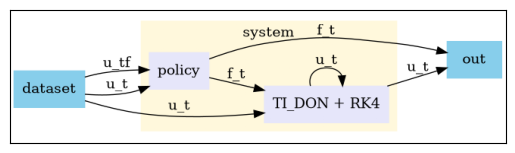

In [20]:
from neuromancer.system import System

# closed-loop system model
system_dpc = System([policy, node_rk4], nsteps=nsteps)
system_dpc.show()

### Dimension checks to the `System`

In [21]:
## dimnension checks for DeepONet inputs and outputs
batch = next(iter(train_loader))
for k, v in batch.items():
    if hasattr(v, "shape"):
        print(k, v.shape)
    else:
        print(k, type(v), v)


u_t torch.Size([25, 1, 100])
u_tf torch.Size([25, 101, 100])
trunk_inputs torch.Size([25, 100, 1])
name <class 'str'> train


Because `System` always keeps the initial state and appends the prediction each step.

With `nsteps=100`:

input `u_t` has shape `(B,1,100)` (the initial state)
after ten step it appends the predicted `u_{t+10}`
so output `u_t` becomes `(B,101,100) = [u_t, u_{t+1}, ..., u_{t+100}]`

In [22]:
tensor_batch = {k: v.to(device) for k, v in batch.items() if hasattr(v, "shape")}
system_dpc = system_dpc.to(device)
out = system_dpc(tensor_batch)
print("System out keys:", out.keys())
print("f_t out shape:", out["f_t"].shape)  # has u_t and u_t+1
print("u_t out shape:", out["u_t"].shape)  # has u_t and u_t+1
print("u_tf out shape:", out["u_tf"].shape)  # has u_t and u_t+1

System out keys: dict_keys(['u_t', 'u_tf', 'trunk_inputs', 'f_t'])
f_t out shape: torch.Size([25, 100, 4])
u_t out shape: torch.Size([25, 101, 100])
u_tf out shape: torch.Size([25, 101, 100])


## Tracking loss

### Objective and Constraints in NeuroMANCER

**Loss Function.** We utilize a fully data-driven approach using Mean Squared Error (MSE). The loss is calculated by comparing the ground truth data $u_{t+1}$ against the predicted state $\hat{u}_{t+1}$, which is obtained by integrating the DeepONet output through an RK4 step:

$$
\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \left( \hat{u}_{t+1}^{(i)} - u_{t+1}^{(i)} \right)^2
$$

In [ ]:
from neuromancer.constraint import variable, Objective
from neuromancer.loss import PenaltyLoss

y = variable("u_t")[:, -1, :]  # (B, T+1, nx)
r = variable("u_tf")[:, -1, :]  # (B, T+1, nx)

track = (y - r) ** 2
mse_obj = Objective(track, metric=torch.mean, name="mse_loss")

loss = PenaltyLoss(objectives=[mse_obj], constraints=[])


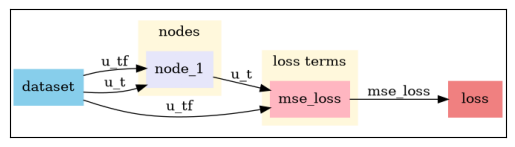

In [24]:
from neuromancer.problem import Problem

problem = Problem([system_dpc], loss)
# plot computational graph
problem.show()

## Training the control policy

In [25]:
# result_dir = './'
epochs = int(1)  # 10 passes of 1000 steps each
log_every = 1
lr = 1e-3
transition_steps = 2000
decay_rate = 0.9

The learning rate is updated at each optimizer step using an exponential decay schedule,
$$
\eta_k = \eta_0 \, \gamma^{\,k / T},
$$
where $\eta_0$ is the base learning rate (`lr`), $ \gamma \in (0,1) $ is the decay rate (`decay_rate`), $ k $ denotes the optimizer step index, and $ T $ is the transition scale (`transition_steps`) controlling the decay speed.


In [26]:
from torch.optim.lr_scheduler import LambdaLR
from neuromancer.callbacks import Callback

optimizer = torch.optim.Adam(problem.parameters(), lr=lr)


def exponential_decay(step: int) -> float:
    """Exponential learning-rate decay applied per optimizer step."""
    return decay_rate ** (step / transition_steps)


scheduler = LambdaLR(optimizer, lr_lambda=exponential_decay)

The custom callback `StepLRSchedulerCallback` updates the learning rate at every training step (batch) and optionally logs the training loss at a fixed step interval.

It gives the printed format:
`epoch: <epoch> step: <step_in_epoch> <loss_name>: <loss_value>`

In [27]:
class StepLRSchedulerCallback(Callback):
    """
    Scheduler that steps every batch end, and logs loss every `log_every`.

    Args:
        scheduler: Learning rate scheduler to step.
        log_every: Frequency of logging loss (in number of steps). If 0, no logging.
        global_step: Internal counter for total steps taken.
        epoch_step: Counter for steps within the current epoch.
        step_indices: List of global step indices where loss was logged.
        step_losses: List of losses corresponding to the logged step indices.
    """

    def __init__(self, scheduler, log_every=1):
        super().__init__()
        self.scheduler = scheduler
        self.log_every = log_every
        self.global_step = 0
        self._last_epoch = None
        self.epoch_step = 0
        self.step_indices = []
        self.step_losses = []

    def end_batch(self, trainer, output):
        if self._last_epoch != trainer.current_epoch:
            self._last_epoch = trainer.current_epoch
            self.epoch_step = 0

        self.scheduler.step()

        if self.log_every and self.epoch_step % self.log_every == 0:
            loss = output.get(trainer.train_metric)
            if loss is not None:
                loss_val = loss.detach().cpu().item()
                print(
                    f"epoch: {trainer.current_epoch} step: {self.epoch_step} "
                    f"{trainer.train_metric}: {loss_val:.6g}"
                )
                self.step_indices.append(self.global_step)
                self.step_losses.append(loss_val)

        self.epoch_step += 1
        self.global_step += 1


lr_callback = StepLRSchedulerCallback(scheduler, log_every=100)  # set as needed

### Construct Trainer and solve the problem

In [28]:
from neuromancer.trainer import Trainer

trainer = Trainer(
    problem.to(device),
    train_data=train_loader,
    # dev_data=dev_loader,        # optional
    test_data=test_loader,
    optimizer=optimizer,
    callback=lr_callback,
    epochs=epochs,
    epoch_verbose=1,
    train_metric="train_loss",
    dev_metric="train_loss",  # or "dev_loss" if you use dev_data
    eval_metric="train_loss",
    test_metric="test_loss",
    warmup=epochs,
    device=device,
)

Sanity checks for grad passing in policy, tidon and loss

In [29]:
print(
    "policy params require grad:", any(p.requires_grad for p in policyMLP.parameters())
)
print("model params require grad:", any(p.requires_grad for p in tidon.parameters()))

batch = next(iter(train_loader))

batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
# batch.pop("f_t", None)  # remove dataset controls
print(batch.keys())


policy params require grad: True
model params require grad: False
dict_keys(['u_t', 'u_tf', 'trunk_inputs', 'name'])


In [30]:
out = problem(batch)
print(out.keys())  # e.g. "train_loss" if name == "train"
print("loss requires grad:", out["train_loss"].requires_grad)

dict_keys(['train_u_t', 'train_u_tf', 'train_trunk_inputs', 'train_name', 'train_f_t', 'train_130237989841008', 'train_130237989784608', 'train_130237989547968', 'train_130237989437712', 'train_130237989550992', 'train_130237989550992_<built-in method mean of type object at 0x7677733d6c20>', 'train_objective_loss', 'train_penalty_loss', 'train_loss'])
loss requires grad: True


In [ ]:
%%time
best_model = trainer.train()

epoch: 0 step: 0 train_loss: 1.39336
epoch: 0 step: 100 train_loss: 0.0139102
epoch: 0 step: 200 train_loss: 0.0127417
epoch: 0 step: 300 train_loss: 0.00980454
epoch: 0 step: 400 train_loss: 0.01848
epoch: 0 step: 500 train_loss: 0.00183332
epoch: 0 step: 600 train_loss: 0.000979846
epoch: 0 step: 700 train_loss: 0.00603812


In [ ]:
# ---- save weights for MIONetCartesianProd (no Trainer needed later) ----
# save_path = "tidon_MIOnet_state_dict.pt"
# torch.save(net.state_dict(), save_path)

In [81]:
# load best trained model
trainer.dev_data = trainer.train_data  # workaround for replacing dev set to match keys
best_outputs = trainer.test(best_model)
problem.load_state_dict(best_model)

<All keys matched successfully>

In [82]:
train_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["train"]]
mean_test_loss = best_outputs["mean_test_loss"].detach().cpu().numpy()
print(f"mean_test_loss: {mean_test_loss}")
print(f"len(train_loss_history): {len(train_loss_history)}")


mean_test_loss: 0.47909873723983765
len(train_loss_history): 4


## Plot loss history w/ mean test loss

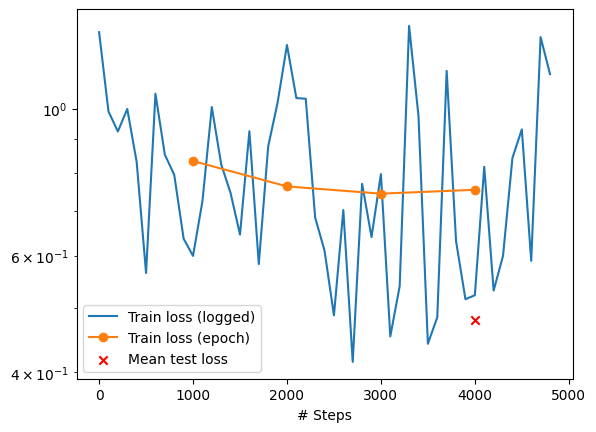

In [83]:
epoch_steps = (np.arange(len(train_loss_history)) + 1) * steps_per_epoch

plt.semilogy(
    lr_callback.step_indices, lr_callback.step_losses, label="Train loss (logged)"
)
plt.semilogy(epoch_steps, train_loss_history, "o-", label="Train loss (epoch)")

plt.scatter(
    epoch_steps[-1],
    mean_test_loss,
    label="Mean test loss",
    c="red",
    marker="x",
)

plt.xlabel("# Steps")
plt.legend()
plt.show()


## Test time predictions

### Why `System` makes autoregressive rollouts cleaner

Using `System` streamlines multi‑step inference because it **owns the rollout loop**. You set `system.nsteps`, pass a single batched input (`u_t`, `f_t`), and get the full trajectory back in one call.

With `System`, multi‑step rollout becomes a **single forward pass** instead of a custom loop, which is cleaner, less error‑prone, and easier to maintain.


In [ ]:
def autoregressive_rollout(sample_id_value, rollout_steps=None):
    system = dynamics_model.to(device)
    system.eval()

    with torch.no_grad():
        u0 = solutions[sample_id_value, 0, :].float().to(device)
        true_states = solutions[sample_id_value, :, :].float().to(device)
        control_seq = controls[sample_id_value, :, :].float().to(device)

        if rollout_steps is None:
            rollout_steps = control_seq.shape[0]
        system.nsteps = rollout_steps  # change nsteps for full rollout

        batch = {
            "u_t": u0.unsqueeze(0).unsqueeze(1),  # (B, 1, N)
            "f_t": control_seq[:rollout_steps].unsqueeze(0),  # (B, T, 4)
        }
        out = system(batch)
        rollout_pred = out["u_t"].squeeze(0)  # (T+1, N)

        true_traj = true_states[: rollout_steps + 1]
        mse_loss = torch.mean((true_traj - rollout_pred) ** 2)
        rel_l2_error = torch.linalg.norm(true_traj - rollout_pred) / torch.linalg.norm(
            true_traj
        )

    return mse_loss, rel_l2_error, rollout_pred, true_traj


In [ ]:
sample_id = 12  # change this to test other samples
mse_loss, rel_l2_error, rollout_pred, true_states = autoregressive_rollout(sample_id)
print(mse_loss.item(), rel_l2_error.item())

0.0028591081500053406 0.05589091032743454


In [ ]:
import matplotlib.gridspec as gridspec


def plot_rollout_results(
    true_states,
    rollout_pred,
    x_cord,
    dt_value,
    sample_id_value,
):
    x_axis = x_cord.squeeze()
    T_plus_1 = true_states.shape[0]
    time_axis = np.linspace(0, dt_value * (T_plus_1 - 1), T_plus_1)
    error = np.abs(true_states - rollout_pred)

    vmin = float(min(true_states.min(), rollout_pred.min()))
    vmax = float(max(true_states.max(), rollout_pred.max()))

    fig = plt.figure(figsize=(20, 10))
    gs = gridspec.GridSpec(
        3,
        3,
        height_ratios=[20, 0.3, 1.0],
        width_ratios=[1, 1, 1],
        hspace=0.15,
        wspace=0.2,
        bottom=0.15,
        top=0.88,
        left=0.08,
        right=0.95,
    )

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
    ax2 = fig.add_subplot(gs[0, 2], sharey=ax0)

    im0 = ax0.contourf(
        x_axis, time_axis, true_states, levels=120, cmap="inferno", vmin=vmin, vmax=vmax
    )
    ax0.set_title("FDM Prediction", fontsize=22)
    ax0.set_xlabel("x", fontsize=20)
    ax0.set_ylabel("t", fontsize=20)
    ax0.tick_params(labelsize=18)

    im1 = ax1.contourf(
        x_axis,
        time_axis,
        rollout_pred,
        levels=120,
        cmap="inferno",
        vmin=vmin,
        vmax=vmax,
    )
    ax1.set_title("TI DON Prediction", fontsize=22)
    ax1.set_xlabel("x", fontsize=20)
    ax1.tick_params(labelsize=18, labelleft=False)

    im2 = ax2.contourf(x_axis, time_axis, error, levels=120, cmap="magma")
    ax2.set_title("Absolute Error", fontsize=22)
    ax2.set_xlabel("x", fontsize=20)
    ax2.tick_params(labelsize=18, labelleft=False)

    cbar_ax1 = fig.add_subplot(gs[2, 0:2])
    cbar1 = fig.colorbar(im1, cax=cbar_ax1, orientation="horizontal")
    cbar1.set_label("u", fontsize=20)
    cbar1.ax.tick_params(labelsize=18)

    cbar_ax2 = fig.add_subplot(gs[2, 2])
    cbar2 = fig.colorbar(im2, cax=cbar_ax2, orientation="horizontal")
    cbar2.set_label("Abs. Error", fontsize=20)
    cbar2.ax.tick_params(labelsize=18)

    plt.show()
